## Support Vector Machine(SVM)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, classification_report)
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [2]:
import warnings
warnings.filterwarnings("ignore")

### Exploration

In [3]:
df = pd.read_csv('mushroom.csv')
df.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [4]:
#Dropping Unnamed: 0
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,sunken,scaly,white,no,anise,descending,distant,broad,pink,tapering,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,enlarging,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,tapering,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,bell,scaly,pink,yes,fishy,notched,close,broad,orange,enlarging,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,enlarging,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [5]:
print(df.dtypes)

cap_shape                       str
cap_surface                     str
cap_color                       str
bruises                         str
odor                            str
gill_attachment                 str
gill_spacing                    str
gill_size                       str
gill_color                      str
stalk_shape                     str
stalk_root                      str
stalk_surface_above_ring        str
stalk_surface_below_ring        str
stalk_color_above_ring          str
stalk_color_below_ring          str
veil_type                       str
veil_color                      str
ring_number                     str
ring_type                       str
spore_print_color               str
population                      str
habitat                         str
class                           str
stalk_height                float64
cap_diameter                float64
dtype: object


In [6]:
df.shape

(2000, 25)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cap_shape                 2000 non-null   str    
 1   cap_surface               2000 non-null   str    
 2   cap_color                 2000 non-null   str    
 3   bruises                   2000 non-null   str    
 4   odor                      2000 non-null   str    
 5   gill_attachment           2000 non-null   str    
 6   gill_spacing              2000 non-null   str    
 7   gill_size                 2000 non-null   str    
 8   gill_color                2000 non-null   str    
 9   stalk_shape               2000 non-null   str    
 10  stalk_root                2000 non-null   str    
 11  stalk_surface_above_ring  2000 non-null   str    
 12  stalk_surface_below_ring  2000 non-null   str    
 13  stalk_color_above_ring    2000 non-null   str    
 14  stalk_color_below_r

In [8]:
df.isnull().sum()

cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
class                       0
stalk_height                0
cap_diameter                0
dtype: int64

In [9]:
#Encoding all categorical columns
categorical_cols = df.select_dtypes(include="str").columns
encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

### Visualizations

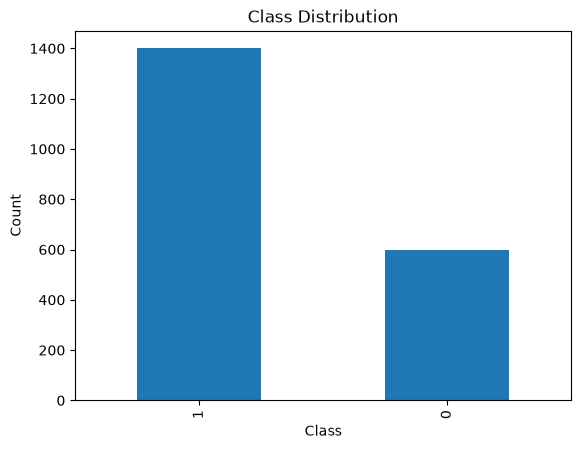

In [10]:
#Countplot
df["class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

* The dataset contains two classes represented by 0 and 1 after label encoding.
* Class 1 has approximately 1400 samples, while Class 0 has around 600 samples.
* Class 1 has a noticeably higher number of samples than Class 0.
* The dataset is moderately imbalanced, with Class 1 occurring more frequently than Class 0.
* The difference in class frequencies should be considered while evaluating the SVM model's performance.

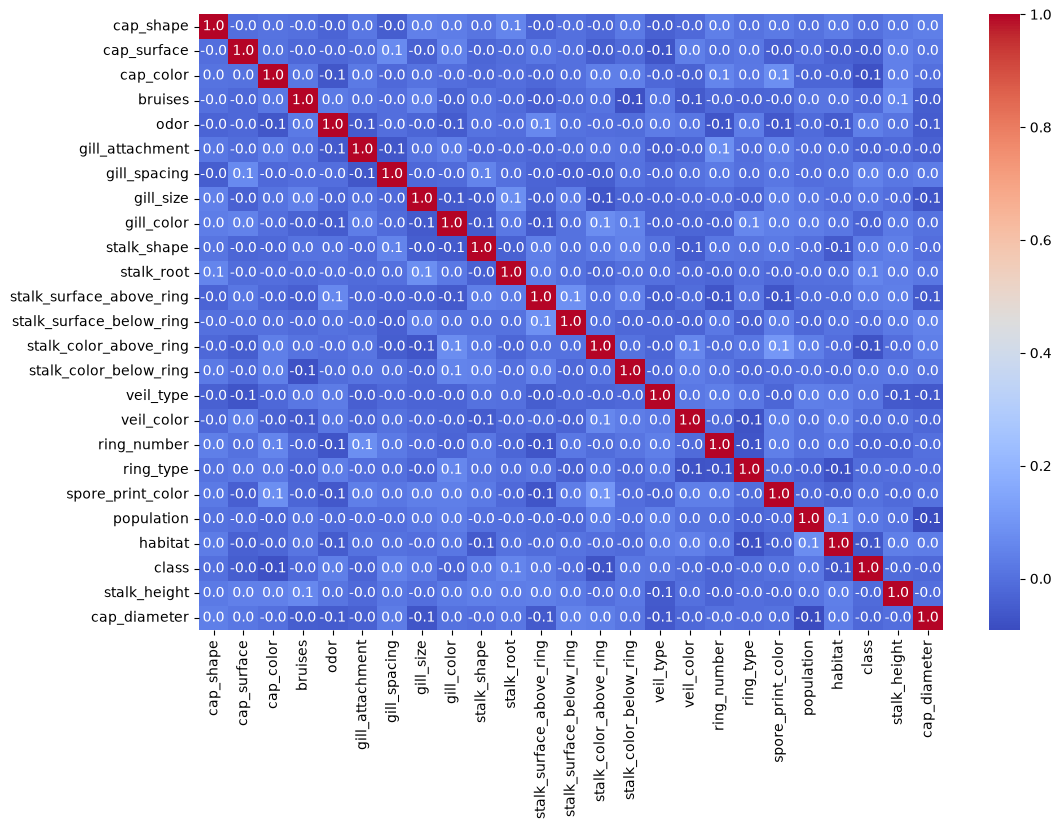

In [11]:
#Correlation
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True, fmt=".1f")
plt.show()

* The heatmap shows that most features have weak correlations with one another.
* Most correlation values are close to zero, indicating low linear relationships between variables.
* No strong positive or negative correlations are observed among the features.
* The diagonal values are equal to 1 because each feature is perfectly correlated with itself.
* The absence of highly correlated features suggests that multicollinearity is not a major concern in this dataset.
* The target variable (class) does not exhibit a strong linear correlation with any single feature, indicating that multiple features together may be required for accurate classification.


### SVM(Linear)

In [12]:
#Simple Linear SVM
X = df.drop("class", axis=1)
y = df["class"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [13]:
#StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
print(X_train.shape)
print(X_test.shape)

(1600, 24)
(400, 24)


In [15]:
print(y_train.value_counts())
print(y_test.value_counts())

class
1    1120
0     480
Name: count, dtype: int64
class
1    280
0    120
Name: count, dtype: int64


In [16]:
#Training SVM (linear)
model = SVC(kernel="linear", random_state=42)
model.fit(X_train, y_train)
linear_pred = model.predict(X_test)

In [17]:
print("Accuracy :", accuracy_score(y_test,linear_pred))
print("Precision:", precision_score(y_test,linear_pred, average="weighted"))
print("Recall   :", recall_score(y_test,linear_pred, average="weighted"))
print("F1-score :", f1_score(y_test,linear_pred, average="weighted"))

Accuracy : 0.7
Precision: 0.49
Recall   : 0.7
F1-score : 0.5764705882352941


In [18]:
print("\nClassification Report")
print(classification_report(y_test,linear_pred))


Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       120
           1       0.70      1.00      0.82       280

    accuracy                           0.70       400
   macro avg       0.35      0.50      0.41       400
weighted avg       0.49      0.70      0.58       400



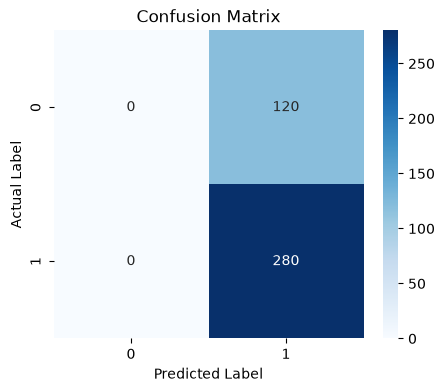

In [19]:
#Confusion Matrix
cm = confusion_matrix(y_test, linear_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

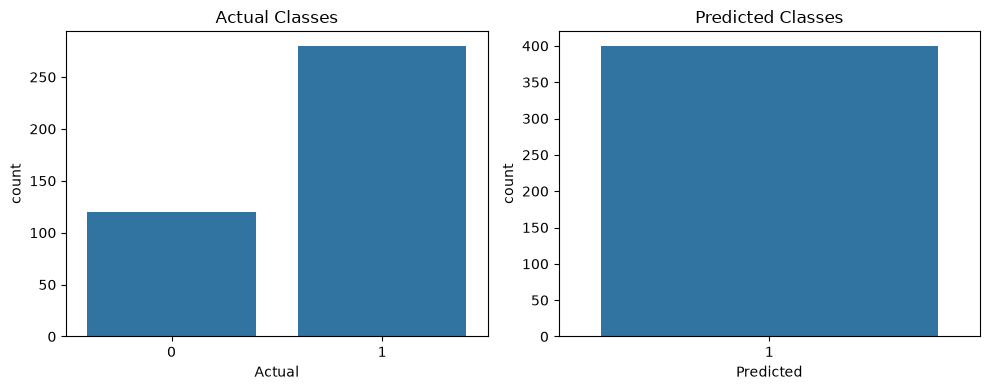

In [20]:
#Visualization of SVM Results
comparison = pd.DataFrame({"Actual": y_test.values,"Predicted": linear_pred})
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.countplot(x="Actual", data=comparison)
plt.title("Actual Classes")
plt.subplot(1,2,2)
sns.countplot(x="Predicted", data=comparison)
plt.title("Predicted Classes")
plt.tight_layout()
plt.show()

The Linear SVM achieved an accuracy of 70% but predicted all test samples as Class 1, indicating that a linear decision boundary was insufficient for the dataset

### SVM(Rbf)

In [21]:
#Training SVM (rbf)
model = SVC(kernel="rbf", random_state=42)
model.fit(X_train, y_train)
rbf_pred = model.predict(X_test)

In [22]:
print("Accuracy :", accuracy_score(y_test,rbf_pred))
print("Precision:", precision_score(y_test,rbf_pred, average="weighted"))
print("Recall   :", recall_score(y_test,rbf_pred, average="weighted"))
print("F1-score :", f1_score(y_test,rbf_pred, average="weighted"))

Accuracy : 0.775
Precision: 0.7890704800817161
Recall   : 0.775
F1-score : 0.7363092498849517


In [23]:
print("\nClassification Report")
print(classification_report(y_test,rbf_pred))


Classification Report
              precision    recall  f1-score   support

           0       0.84      0.31      0.45       120
           1       0.77      0.97      0.86       280

    accuracy                           0.78       400
   macro avg       0.80      0.64      0.65       400
weighted avg       0.79      0.78      0.74       400



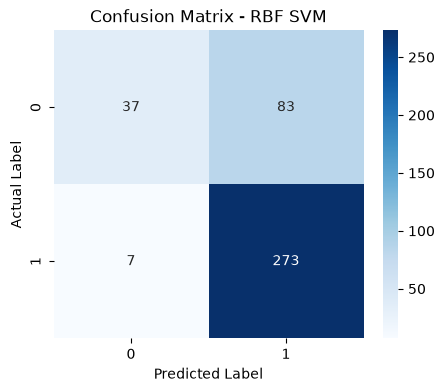

In [24]:
#Confusion Matrix 
cm = confusion_matrix(y_test, rbf_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - RBF SVM")
plt.show()

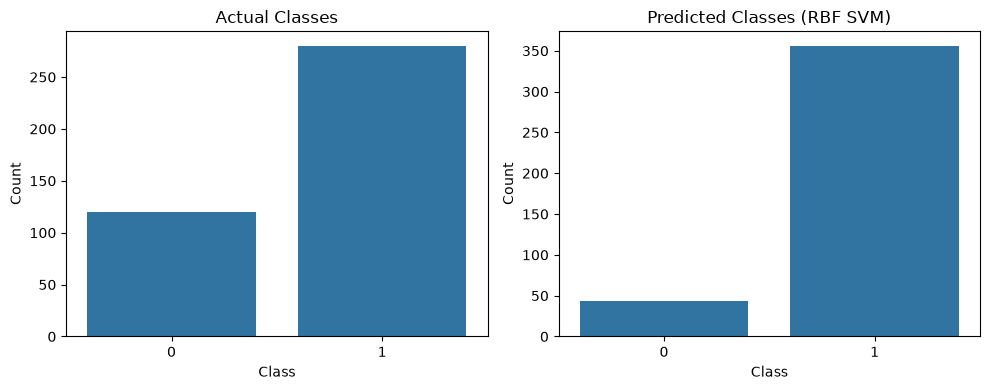

In [25]:
#Actual vs Predicted Classes (RBF SVM)
comparison = pd.DataFrame({"Actual": y_test.values,"Predicted": rbf_pred})
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.countplot(x="Actual", data=comparison)
plt.title("Actual Classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.subplot(1,2,2)
sns.countplot(x="Predicted", data=comparison)
plt.title("Predicted Classes (RBF SVM)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Kernel Comparison

In [26]:
#Kernel Comparison
results = pd.DataFrame({
    "Kernel":["Linear","RBF"],
    "Accuracy":[accuracy_score(y_test,linear_pred),accuracy_score(y_test,rbf_pred)],
    "Precision":[precision_score(y_test,linear_pred),precision_score(y_test,rbf_pred)],
    "Recall":[recall_score(y_test,linear_pred),recall_score(y_test,rbf_pred)],
    "F1-score":[f1_score(y_test,linear_pred),f1_score(y_test,rbf_pred)]
})
print(results)

   Kernel  Accuracy  Precision  Recall  F1-score
0  Linear     0.700   0.700000   1.000  0.823529
1     RBF     0.775   0.766854   0.975  0.858491


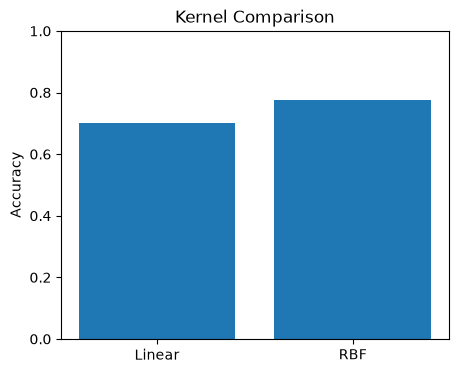

In [27]:
accuracy = [accuracy_score(y_test, linear_pred),accuracy_score(y_test, rbf_pred)]
plt.figure(figsize=(5,4))
plt.bar(["Linear","RBF"], accuracy)
plt.ylabel("Accuracy")
plt.title("Kernel Comparison")
plt.ylim(0,1)
plt.show()

### Parameter Tuning

In [28]:
c_values = [0.1, 1, 10]
gamma_values = [0.01, 0.1, 1]
tuning_results = []
for c in c_values:
    for g in gamma_values:
        model = SVC(kernel="rbf",C=c,gamma=g,random_state=42)
        model.fit(X_train, y_train)
        temp = model.predict(X_test)
        tuning_results.append([c,g,accuracy_score(y_test, temp)])
tuning_results = pd.DataFrame(tuning_results,columns=["C","Gamma","Accuracy"])
print(tuning_results)

      C  Gamma  Accuracy
0   0.1   0.01    0.7000
1   0.1   0.10    0.7000
2   0.1   1.00    0.7000
3   1.0   0.01    0.7000
4   1.0   0.10    0.8450
5   1.0   1.00    0.8575
6  10.0   0.01    0.7325
7  10.0   0.10    0.8625
8  10.0   1.00    0.8575


### SVM(Optimized)

In [29]:
#Best Parameters
best = tuning_results.loc[tuning_results["Accuracy"].idxmax()]
print("Best C Value :", best["C"])
print("Best Gamma   :", best["Gamma"])
print("Best Accuracy:", best["Accuracy"])

Best C Value : 10.0
Best Gamma   : 0.1
Best Accuracy: 0.8625


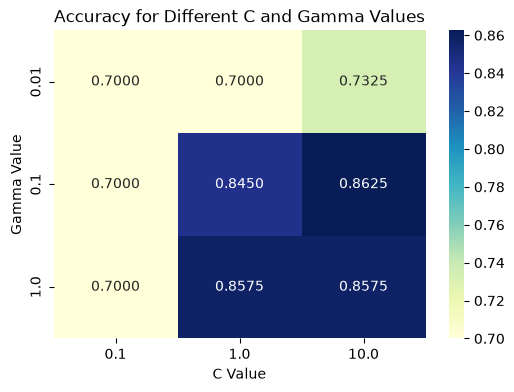

In [30]:
#Accuracy Heatmap
pivot = tuning_results.pivot(index="Gamma",columns="C",values="Accuracy")
plt.figure(figsize=(6,4))
sns.heatmap(pivot,annot=True,fmt=".4f",cmap="YlGnBu")
plt.title("Accuracy for Different C and Gamma Values")
plt.xlabel("C Value")
plt.ylabel("Gamma Value")
plt.show()

In [31]:
#Optimized SVM
best_model = SVC(kernel="rbf",C=best["C"],gamma=best["Gamma"],random_state=42)
best_model.fit(X_train, y_train)
orbf_pred = best_model.predict(X_test)

In [32]:
print("Accuracy :", accuracy_score(y_test, orbf_pred))
print("Precision:", precision_score(y_test, orbf_pred, average="weighted"))
print("Recall   :", recall_score(y_test, orbf_pred, average="weighted"))
print("F1-score :", f1_score(y_test, orbf_pred, average="weighted"))

Accuracy : 0.8625
Precision: 0.8658925924518264
Recall   : 0.8625
F1-score : 0.8542300995948544


In [33]:
print("\nClassification Report\n")
print(classification_report(y_test, orbf_pred))


Classification Report

              precision    recall  f1-score   support

           0       0.89      0.62      0.73       120
           1       0.85      0.97      0.91       280

    accuracy                           0.86       400
   macro avg       0.87      0.79      0.82       400
weighted avg       0.87      0.86      0.85       400



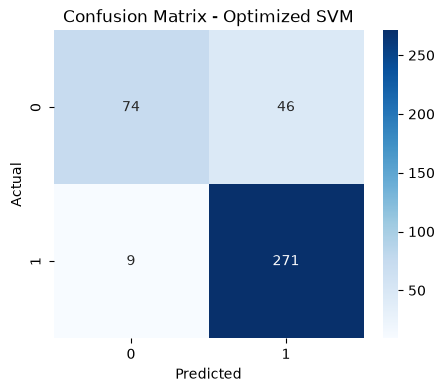

In [34]:
cm = confusion_matrix(y_test, orbf_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Optimized SVM")
plt.show()

### SVM(Polynomial)

In [35]:
poly_model = SVC(kernel="poly", degree=3, random_state=42)
poly_model.fit(X_train, y_train)
poly_pred = poly_model.predict(X_test)

In [36]:
print("Polynomial Kernel Results")
print("Accuracy :", accuracy_score(y_test, poly_pred))
print("Precision:", precision_score(y_test, poly_pred, average="weighted"))
print("Recall   :", recall_score(y_test, poly_pred, average="weighted"))
print("F1-score :", f1_score(y_test, poly_pred, average="weighted"))

Polynomial Kernel Results
Accuracy : 0.8125
Precision: 0.8341308248599859
Recall   : 0.8125
F1-score : 0.7862101391155241


In [37]:
print(classification_report(y_test, poly_pred))

              precision    recall  f1-score   support

           0       0.92      0.41      0.57       120
           1       0.80      0.99      0.88       280

    accuracy                           0.81       400
   macro avg       0.86      0.70      0.72       400
weighted avg       0.83      0.81      0.79       400



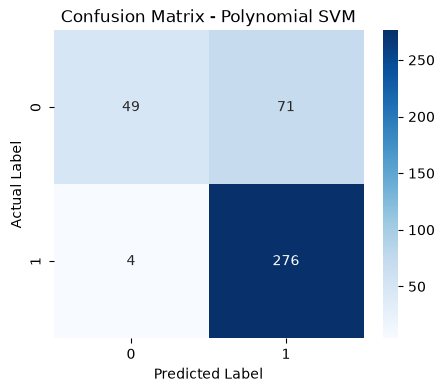

In [38]:
cm = confusion_matrix(y_test, poly_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Polynomial SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

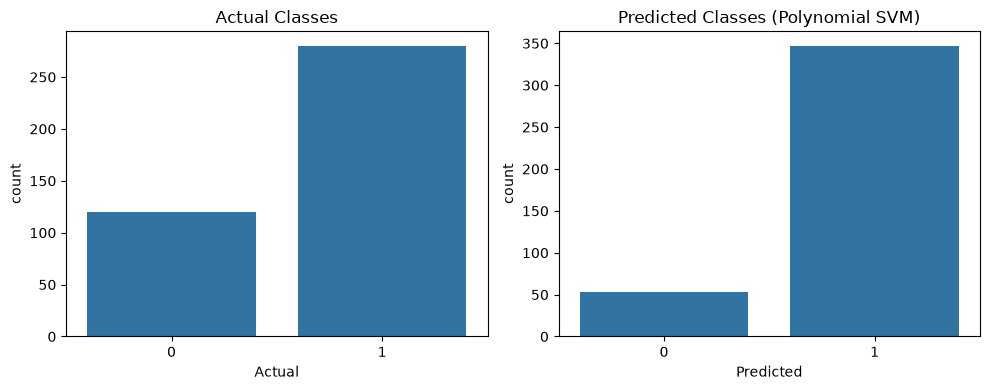

In [39]:
comparison = pd.DataFrame({"Actual": y_test.values,"Predicted": poly_pred})
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.countplot(x="Actual", data=comparison)
plt.title("Actual Classes")
plt.subplot(1,2,2)
sns.countplot(x="Predicted", data=comparison)
plt.title("Predicted Classes (Polynomial SVM)")
plt.tight_layout()
plt.show()

### Comparison of all models

In [40]:
comparison = pd.DataFrame({
    "Kernel": ["Linear", "RBF", "Polynomial", "Optimized RBF"],
    "Accuracy": [
        accuracy_score(y_test, linear_pred),
        accuracy_score(y_test, rbf_pred,),
        accuracy_score(y_test, poly_pred),
        accuracy_score(y_test, orbf_pred)
        
    ],
    "Precision": [
        precision_score(y_test, linear_pred,average="weighted"),
        precision_score(y_test, rbf_pred,average="weighted"),
        precision_score(y_test, poly_pred,average="weighted"),
        precision_score(y_test, orbf_pred,average="weighted")
    ],
    "Recall": [
        recall_score(y_test, linear_pred,average="weighted"),
        recall_score(y_test, rbf_pred,average="weighted"),
        recall_score(y_test, poly_pred,average="weighted"),
        recall_score(y_test, orbf_pred,average="weighted")
    ],
    "F1-score": [
        f1_score(y_test, linear_pred,average="weighted"),
        f1_score(y_test, rbf_pred,average="weighted"),
        f1_score(y_test, poly_pred,average="weighted"),
        f1_score(y_test, orbf_pred,average="weighted")

    ]
})

print(comparison)

          Kernel  Accuracy  Precision  Recall  F1-score
0         Linear    0.7000   0.490000  0.7000  0.576471
1            RBF    0.7750   0.789070  0.7750  0.736309
2     Polynomial    0.8125   0.834131  0.8125  0.786210
3  Optimized RBF    0.8625   0.865893  0.8625  0.854230


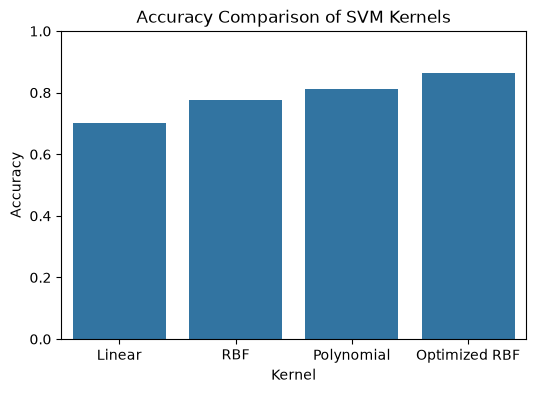

In [41]:
plt.figure(figsize=(6,4))
sns.barplot(x="Kernel",y="Accuracy",data=comparison)
plt.title("Accuracy Comparison of SVM Kernels")
plt.ylim(0,1)
plt.show()

### Comparison and Analysis

**Strengths and Weaknesses**

Strengths:
* Works well with high-dimensional datasets.
* Provides high classification accuracy.
* Kernel functions allow handling of non-linear data.

Weakness:
* Selecting the correct kernel and hyperparameters is important.
* Training can be slow for very large datasets.
* Less interpretable than models like Decision Trees.

**Practical Applications**

* Mushroom toxicity prediction
* Medical diagnosis
* Spam email detection
* Image classification
* Face recognition
* Fraud detection
* Text classification